# Model Training and Bias Analysis

## Imports

In [1]:
import subprocess
import xgboost
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Configuration

In [2]:
CSV_PATH = "combined_adapted_with_counts.csv" #Combined Dataset
#CSV_PATH = "iowa_adapted_with_counts.csv" #Baseline dataset

OUT = "results/"
SEED = 42
EPOCHS = 50
BATCH_SIZE = 256
LR_NN = 1e-3
DROPOUT = 0.3
TEST_SIZE = 0.20
THRESHOLD = 0.57   # Classification threshhold

import os; os.makedirs(OUT, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Dataset : {CSV_PATH}")
print(f"Threshold: {THRESHOLD}")

Dataset : combined_adapted_with_counts.csv
Threshold: 0.57


## 1. Load & Encode

In [3]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
#df = df.drop_duplicates()
if "source" in df.columns: #The combined dataset contains the source Iowa/Compass
    df = df.drop(columns=["source"])

TARGET = "recidivism"
CAT_COLS = ["race", "age_cat", "offense_classification", "offense_type"]
NUM_COLS = ["priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]

# Keep raw race before encoding for bias analysis
race_col = df["race"].values

# One-Hot Encoding for categoricals
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype="float32")
X_cat = ohe.fit_transform(df[CAT_COLS].astype(str))
ohe_feature_names = ohe.get_feature_names_out(CAT_COLS).tolist()

# Standard scaling for numericals
scaler = StandardScaler()
X_num = scaler.fit_transform(df[NUM_COLS]).astype("float32")

# Combine NUM/CAT 
X = np.concatenate([X_cat, X_num], axis=1).astype("float32")
FEATURES = ohe_feature_names + NUM_COLS

y = df[TARGET].values.astype("float32")

print(f"Rows: {len(df)} | Recidivism rate: {y.mean():.3f} | Features after OHE: {len(FEATURES)}")
print(f"Race distribution: { {r: int((race_col==r).sum()) for r in sorted(set(race_col))} }")
df.head(3)


Rows: 33199 | Recidivism rate: 0.359 | Features after OHE: 20
Race distribution: {'Asian': 224, 'Black': 9807, 'Hispanic': 2221, 'Native American': 520, 'Other': 377, 'White': 20050}


,race,age_cat,offense_classification,offense_type,offense_subtype,recidivism,priors_count,juv_fel_count,juv_misd_count,juv_other_count
0,White,25 - 45,F,Drug,Trafficking,1,7,0,1,0
1,Black,25 - 45,M,Violent,Assault,0,1,0,0,0
2,White,25 - 45,M,Other,Other Criminal,1,10,0,0,0


## 2. Train / Validation / Test Split

In [4]:
X_trainval, X_test, y_trainval, y_test, race_trainval, race_test = train_test_split(
    X, y, race_col, test_size=TEST_SIZE, random_state=SEED, stratify=y)

# For Neural Network
X_train, X_val, y_train, y_val = train_test_split( 
    X_trainval, y_trainval, test_size=0.15, random_state=SEED, stratify=y_trainval)

# This is a weight passed to the logistic regression loss function to punish misclassification as recidivists more than as non-recidvists
# Equivelent of class_weight="balanced" in Pytorch (because we got a Recidivism rate of 0.359)
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_w = float(n_neg / n_pos) # This is a weight passed to the logistic regression loss function to punish missclassification 

print(f"Trainval: {X_trainval.shape} | Val (NN only): {X_val.shape} | Test: {X_test.shape}")
print(f"pos_weight: {pos_w:.3f}  (neg={int(n_neg)}, pos={int(n_pos)})")

Trainval: (26559, 20) | Val (NN only): (3984, 20) | Test: (6640, 20)
pos_weight: 1.782  (neg=14461, pos=8114)


## 3. Neural Network

In [5]:
# Neural Network 128 -> 64 -> 32
class RecidivismNet(nn.Module):
    def __init__(self, input_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def train_nn(X_tr, y_tr, X_v, y_v, input_dim, epochs, pos_w):
    pw = torch.tensor([pos_w], dtype=torch.float32)
    model = RecidivismNet(input_dim=input_dim, dropout=DROPOUT)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_NN, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
                       batch_size=BATCH_SIZE, shuffle=True)
    v_dl = DataLoader(TensorDataset(torch.from_numpy(X_v),  torch.from_numpy(y_v)),
                       batch_size=BATCH_SIZE)
    train_losses, val_aucs = [], []
    for epoch in range(epochs):
        model.train(); epoch_loss = 0.0
        for xb, yb in tr_dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_tr); train_losses.append(epoch_loss)
        model.eval(); vp = []
        with torch.no_grad():
            for xb, _ in v_dl: vp.extend(torch.sigmoid(model(xb)).numpy())
        va = roc_auc_score(y_v, vp); val_aucs.append(va)
        scheduler.step(epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  val_auc={va:.4f}")
    return model, train_losses, val_aucs

def predict_nn(model, X):
    model.eval()
    dl = DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=BATCH_SIZE)
    probs, preds = [], []
    with torch.no_grad():
        for (xb,) in dl:
            logits = model(xb)
            probs.extend(torch.sigmoid(logits).numpy())
            preds.extend((torch.sigmoid(logits) > THRESHOLD).numpy().astype(int))
    return np.array(preds), np.array(probs)

## 4. Computing Bias 

In [6]:
# Computing bias per race.
def compute_bias(y_true, y_pred, race_labels):
    results = {}
    for race in sorted(set(race_labels), key=str):
        mask = race_labels == race
        if mask.sum() < 3: continue
        yt, yp = y_true[mask].astype(int), y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        results[race] = {
            "n": int(mask.sum()),
            "accuracy": accuracy_score(yt, yp),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        }
    return results

def collapse_bias_for_figures(bias_dict):
    collapsed = {}
    other_TP = other_TN = other_FP = other_FN = other_n = 0

    for race, m in bias_dict.items():
        n = m["n"]
        tp = round(m["accuracy"] * n - (1 - m["FPR"]) * (n - round(n * (1 - m["FNR"] - m["accuracy"] + 1))))
        if race in ("Black", "White"):
            collapsed[race] = m
        else:
            other_n += n
            other_FP += round(m["FPR"] * n * (1 - getattr(m, "_pos_rate", 0.5)))
            other_FN += round(m["FNR"] * n * getattr(m, "_pos_rate", 0.5))

    # Average weighted by n
    other_races = {r: m for r, m in bias_dict.items() if r not in ("Black", "White")}
    if other_races:
        total_n = sum(m["n"] for m in other_races.values())
        w_acc = sum(m["accuracy"] * m["n"] for m in other_races.values()) / total_n
        w_fpr = sum(m["FPR"] * m["n"] for m in other_races.values()) / total_n
        w_fnr = sum(m["FNR"] * m["n"] for m in other_races.values()) / total_n
        collapsed["Other"] = {"n": total_n, "accuracy": w_acc, "FPR": w_fpr, "FNR": w_fnr}

    # Display order: Black first, then White, then Other
    ordered = {}
    for key in ("Black", "White", "Other"):
        if key in collapsed:
            ordered[key] = collapsed[key]
    return ordered


## 5. Train All Models

In [7]:
all_bias    = {}
all_metrics = {}

MODEL_COLORS = {
    "Logistic Regression": "#4C72B0",
    "Random Forest" : "#55A868",
    "XGBoost" : "#E8A838",
    "Neural Network" : "#C44E52",
}

#### Logistic Regression ########################################################
print("Logistic Regression:")
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced", C=1.0)
lr_model.fit(X_trainval, y_trainval)
y_prob = lr_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)
acc, auc = accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)
all_bias["Logistic Regression"] = compute_bias(y_test, y_pred, race_test)
all_metrics["Logistic Regression"] = {"accuracy": acc, "auc": auc}
print(f"  acc={acc:.2f}  auc={auc:.2f}")

#### Random Forest ##############################################################
print("Random Forest:")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8,
                                   class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_model.fit(X_trainval, y_trainval)
y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)
acc, auc = accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)
all_bias["Random Forest"] = compute_bias(y_test, y_pred, race_test)
all_metrics["Random Forest"] = {"accuracy": acc, "auc": auc}
print(f"  acc={acc:.2f}  auc={auc:.2f}")

##### XGBoost ###################################################################
print("XGBoost:")
xgb_model = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=pos_w, random_state=SEED,
                            eval_metric="auc", verbosity=0)
xgb_model.fit(X_trainval, y_trainval)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)
acc, auc = accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)
all_bias["XGBoost"] = compute_bias(y_test, y_pred, race_test)
all_metrics["XGBoost"] = {"accuracy": acc, "auc": auc}
print(f"  acc={acc:.2f}  auc={auc:.2f}")

##### Neural Network ############################################################
print("Neural Network:")
nn_model, train_losses, val_aucs = train_nn(
    X_train, y_train, X_val, y_val,
    input_dim=X_train.shape[1], epochs=EPOCHS, pos_w=pos_w)
y_pred, y_prob = predict_nn(nn_model, X_test)
acc, auc = accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)
all_bias["Neural Network"] = compute_bias(y_test, y_pred, race_test)
all_metrics["Neural Network"] = {"accuracy": acc, "auc": auc}
print(f"  acc={acc:.2f}  auc={auc:.2f}")
torch.save(nn_model.state_dict(), OUT + "nn_model.pt")

# Results 
print()
print(f"{'Model':25s}  {'Accuracy':>10}  {'AUC':>10}")
print("=" * 50)
for mname, m in all_metrics.items():
    print(f"{mname:25s}  {m['accuracy']:>10.3f}  {m['auc']:>10.3f}")

Logistic Regression:
  acc=0.63  auc=0.60
Random Forest:
  acc=0.65  auc=0.61
XGBoost:
  acc=0.65  auc=0.61
Neural Network:
  epoch  10/50  loss=0.8660  val_auc=0.6094
  epoch  20/50  loss=0.8631  val_auc=0.6132
  epoch  30/50  loss=0.8620  val_auc=0.6120
  epoch  40/50  loss=0.8617  val_auc=0.6116
  epoch  50/50  loss=0.8606  val_auc=0.6113
  acc=0.64  auc=0.62

Model                        Accuracy         AUC
Logistic Regression             0.625       0.604
Random Forest                   0.647       0.612
XGBoost                         0.647       0.614
Neural Network                  0.644       0.615


## 6. Visualisations

In [8]:
# Collapsing non-Black/White races into "Other" for cleaner figures
all_bias_fig = {
    model_name: collapse_bias_for_figures(bias)
    for model_name, bias in all_bias.items()
}

races_fig = [r for r in ["Black", "White", "Other"] if any(r in b for b in all_bias_fig.values())]

# Assigning a color for each race group
RACE_COLORS = {
    "Black": "#2C3E50",   
    "White": "#4C72B0",   
    "Other": "#95A5A6",   
}

# plot function
def plot_metric(all_bias, races, metric, ylabel, title, ylim, fname):
    model_names = list(all_bias.keys())
    bar_width = 0.2
    x = np.arange(len(races))

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, model_name in enumerate(model_names):
        values = [
            all_bias[model_name].get(race, {}).get(metric, 0)
            for race in races
        ]
        bars = ax.bar(
            x + i * bar_width,
            values,
            bar_width,
            label=model_name,
            color=MODEL_COLORS[model_name],
            alpha=0.85,
        )
        
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(races, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ylim)
    if metric == "accuracy":
        ax.axhline(
            0.5,
            color="grey",
            linestyle="--",
            lw=0.8,
            alpha=0.6,
            label="Random baseline",
        )

    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT + fname, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()



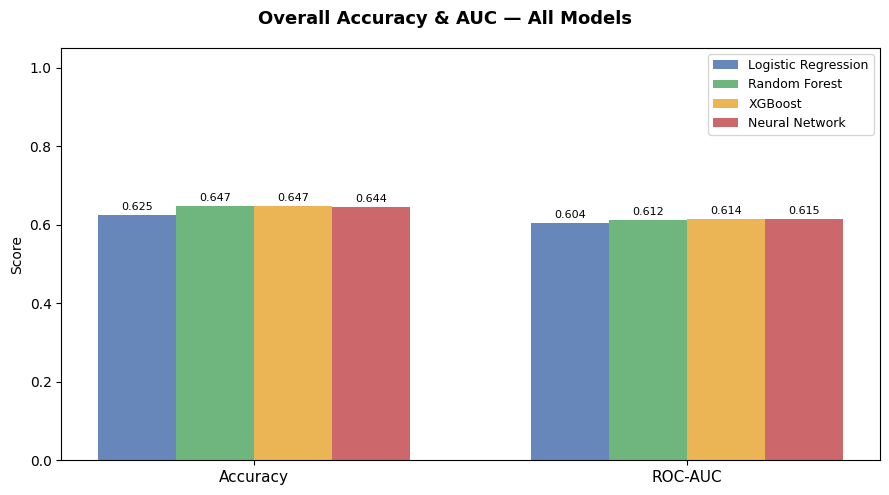

In [9]:
# Overall performance (Accuracy and AUC)
bar_width = 0.18
x = np.arange(2)  

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Overall Accuracy & AUC — All Models", fontsize=13, fontweight="bold")

for i, model_name in enumerate(all_metrics):
    values = [all_metrics[model_name]["accuracy"], all_metrics[model_name]["auc"]]
    bars = ax.bar(
        x + i * bar_width,
        values,
        bar_width,
        label=model_name,
        color=MODEL_COLORS[model_name],
        alpha=0.85,
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(["Accuracy", "ROC-AUC"], fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT + "fig_overall_performance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


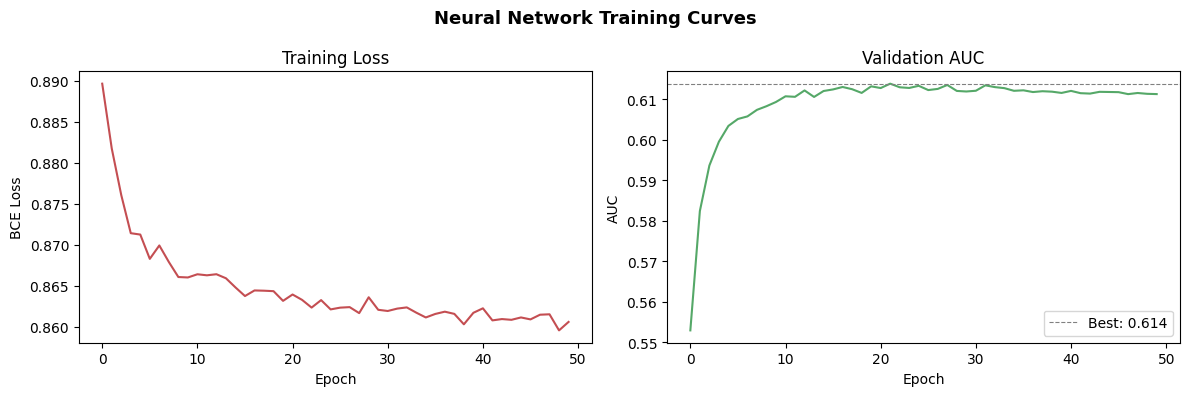

In [10]:
# Neural Network training curves
fig, (ax_loss, ax_auc) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Neural Network Training Curves", fontsize=13, fontweight="bold")

ax_loss.plot(train_losses, color=MODEL_COLORS["Neural Network"])
ax_loss.set_title("Training Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("BCE Loss")

best_auc = max(val_aucs)
ax_auc.plot(val_aucs, color="#55A868")
ax_auc.axhline(best_auc, color="grey", linestyle="--", lw=0.8, label=f"Best: {best_auc:.3f}")
ax_auc.set_title("Validation AUC")
ax_auc.set_xlabel("Epoch")
ax_auc.set_ylabel("AUC")
ax_auc.legend()

plt.tight_layout()
plt.savefig(OUT + "fig_nn_training_curve.png")
plt.show()
plt.close()

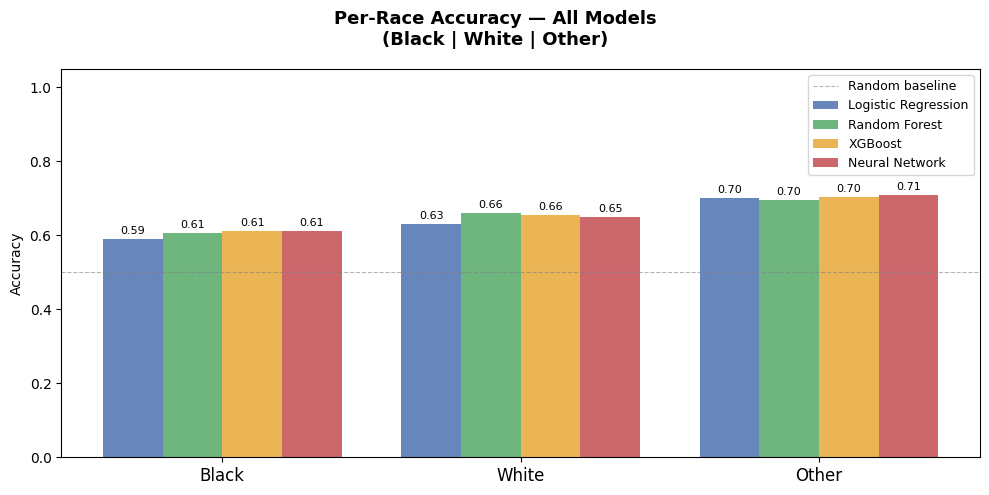

In [11]:
# Per race accuracy
plot_metric(
    all_bias_fig, races_fig,
    metric="accuracy",
    ylabel="Accuracy",
    title="Per-Race Accuracy — All Models\n(Black | White | Other)",
    ylim=1.05,
    fname="fig_per_race_accuracy.png",
)

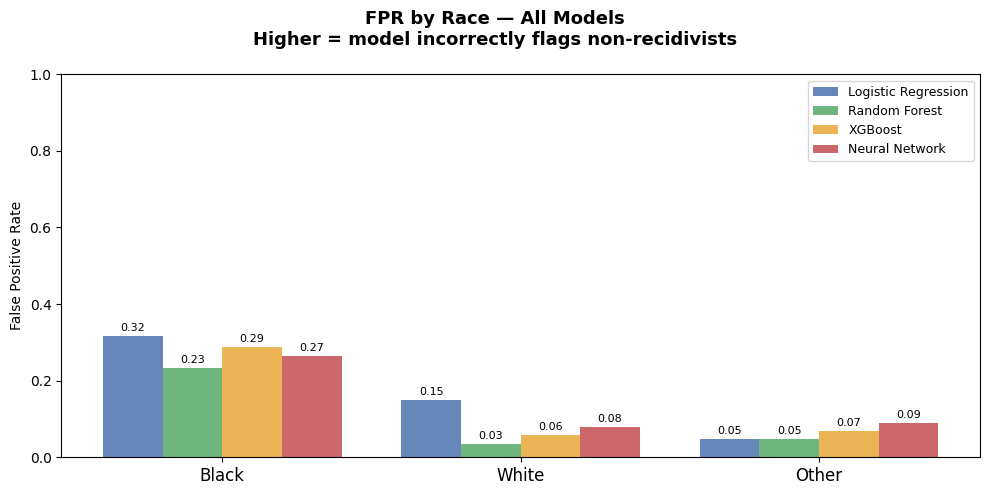

In [12]:
# Per race FPR
plot_metric(
    all_bias_fig, races_fig,
    metric="FPR",
    ylabel="False Positive Rate",
    title="FPR by Race — All Models\nHigher = model incorrectly flags non-recidivists",
    ylim=1.0,
    fname="fig_fpr_by_race.png",
)

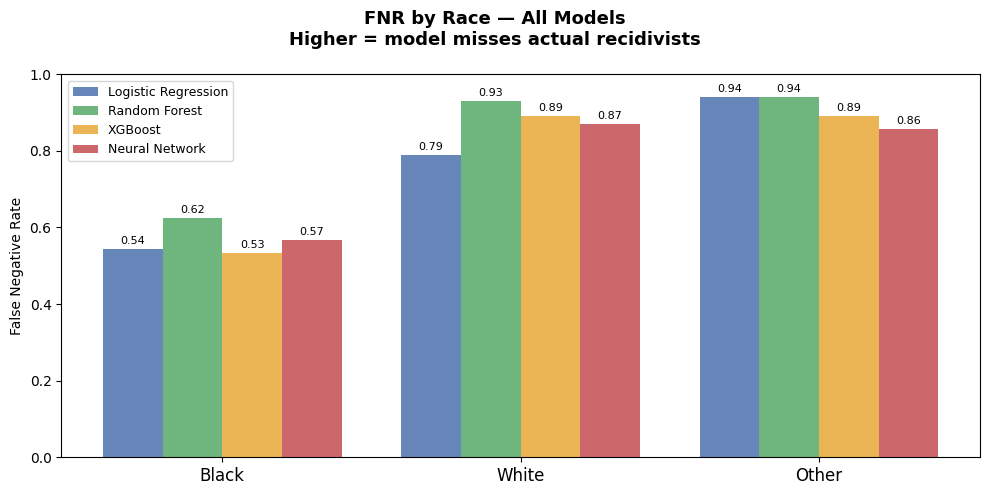

In [13]:
# Per race FNR
plot_metric(
    all_bias_fig, races_fig,
    metric="FNR",
    ylabel="False Negative Rate",
    title="FNR by Race — All Models\nHigher = model misses actual recidivists",
    ylim=1.0,
    fname="fig_fnr_by_race.png",
)

In [14]:
# FPR gap: Black vs White 
print("FPR Gap between black and white")
for model_name, bias in all_bias_fig.items():
    fpr_black = bias.get("Black", {}).get("FPR", 0)
    fpr_white = bias.get("White", {}).get("FPR", 0)
    gap = fpr_black - fpr_white
    print(f"  {model_name:25s}  {gap:+.3f}")

FPR Gap between black and white
  Logistic Regression        +0.166
  Random Forest              +0.198
  XGBoost                    +0.229
  Neural Network             +0.187
